<a href="https://colab.research.google.com/github/saifulroni/clusters_data/blob/main/clustering_lung_cancer_data_processed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-Means Clustering

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import MiniBatchKMeans

In [ ]:
url = 'https://raw.githubusercontent.com/muajnstu/Large_Scale_Implementation_of_DSK_Chain/refs/heads/main/Cleaned_Data/lung_cancer_data_processed_.csv'
df = pd.read_csv(url)
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


In [ ]:
X = df.drop(columns=['LUNG_CANCER'])
y = df['LUNG_CANCER']

X_0 = X[y == 0]
X_1 = X[y == 1]

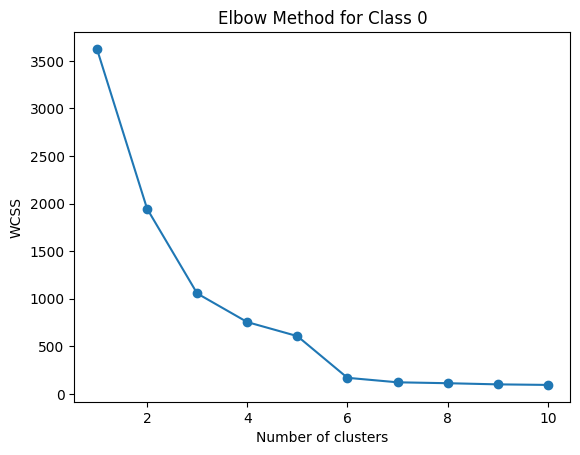

In [ ]:
wcss_0 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_0)
    wcss_0.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss_0, marker='o')
plt.title('Elbow Method for Class 0')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

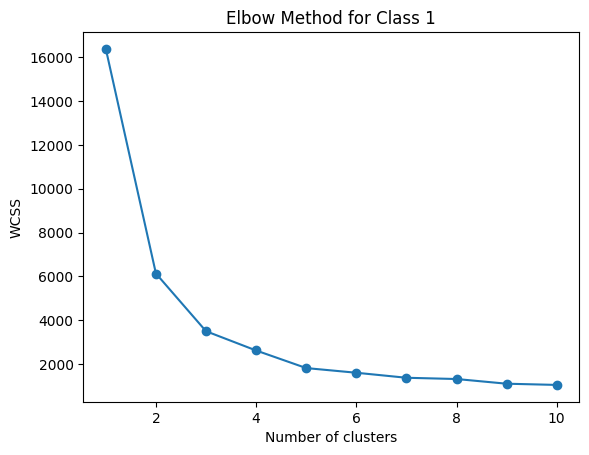

In [ ]:
wcss_1 = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_1)
    wcss_1.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss_1, marker='o')
plt.title('Elbow Method for Class 1')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
n_clusters_0 = 3   # <-- set based on elbow visualization
n_clusters_1 = 4   # <-- set based on elbow visualization

kmeans_0 = KMeans(n_clusters=n_clusters_0, random_state=42)
sub_labels_0 = kmeans_0.fit_predict(X_0)

kmeans_1 = KMeans(n_clusters=n_clusters_1, random_state=42)
sub_labels_1 = kmeans_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 25 samples
Class 0 - Cluster 1: 3 samples
Class 0 - Cluster 2: 10 samples


In [ ]:
counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 1 - Cluster 0: 38 samples
Class 1 - Cluster 1: 63 samples
Class 1 - Cluster 2: 105 samples
Class 1 - Cluster 3: 32 samples


DBSCAN

In [ ]:
dbscan_0 = DBSCAN(eps=0.5, min_samples=5)
sub_labels_0 = dbscan_0.fit_predict(X_0)

dbscan_1 = DBSCAN(eps=0.5, min_samples=5)
sub_labels_1 = dbscan_1.fit_predict(X_1)

In [ ]:
unique_0, counts_0 = np.unique(sub_labels_0, return_counts=True)
for cluster, count in zip(unique_0, counts_0):
    print(f"Class 0 - Cluster {cluster}: {count} samples")

Class 0 - Cluster -1: 38 samples


In [ ]:
unique_1, counts_1 = np.unique(sub_labels_1, return_counts=True)
for cluster, count in zip(unique_1, counts_1):
    print(f"Class 1 - Cluster {cluster}: {count} samples")

Class 1 - Cluster -1: 238 samples


Hierarchical Clustering

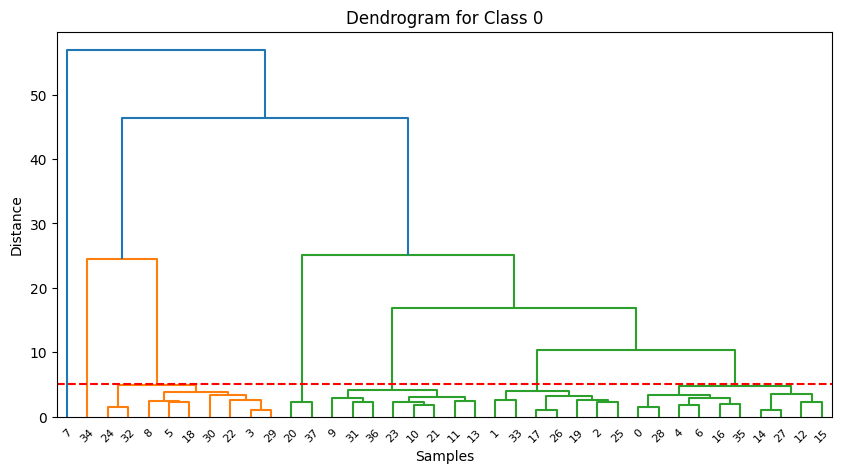

In [ ]:
# Generate linkage matrix for Class 0
Z = linkage(X_0, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram for Class 0")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.axhline(y=5, color='r', linestyle='--')
plt.show()

In [ ]:
Z = linkage(X_0, method='ward')

cluster_labels = fcluster(Z, t=10000, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"Number of clusters: {n_clusters}")

Number of clusters: 1


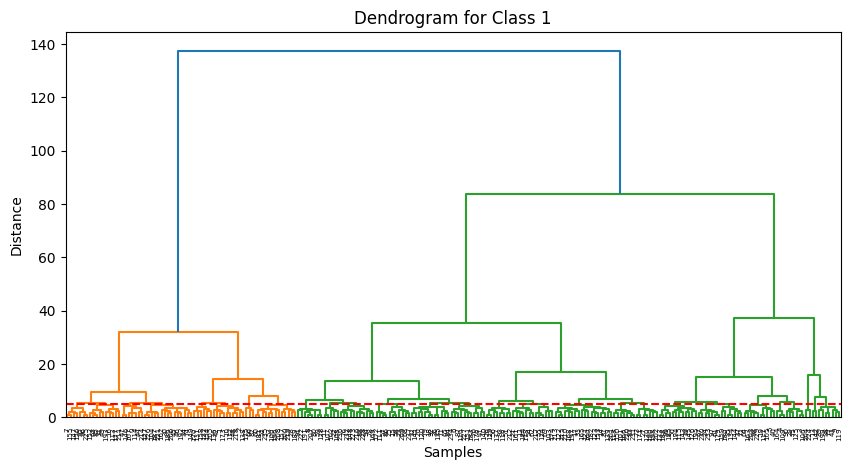

In [ ]:
# Generate linkage matrix for Class 1
Z = linkage(X_1, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram for Class 1")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.axhline(y=5, color='r', linestyle='--')
plt.show()

In [ ]:
Z = linkage(X_1, method='ward')

cluster_labels = fcluster(Z, t=10000, criterion='distance')

n_clusters = len(np.unique(cluster_labels))
print(f"Number of clusters: {n_clusters}")

Number of clusters: 1


second method

In [ ]:
hc_0 = AgglomerativeClustering(n_clusters=3, linkage='average')
sub_labels_0 = hc_0.fit_predict(X_0)

hc_1 = AgglomerativeClustering(n_clusters=4, linkage='average')
sub_labels_1 = hc_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

NameError: name 'np' is not defined

***Spectral Clustering

In [ ]:
def run_spectral_clustering(X_data, class_label):
    best_score = -1
    best_k = None
    best_labels = None

    # Search for the best number of clusters
    for k in range(2, 7):
        sc = SpectralClustering(
            n_clusters=k,
            affinity='nearest_neighbors',  # or 'rbf'
            assign_labels='kmeans',
            random_state=42
        )
        labels = sc.fit_predict(X_data)
        score = silhouette_score(X_data, labels)
        print(f"Class {class_label} | n_clusters={k}, Silhouette Score={score:.4f}")

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    print(f"Best n_clusters for Class {class_label}: {best_k} (Silhouette Score={best_score:.4f})")
    return best_labels, best_k, best_score

In [ ]:
# ---- Run Spectral Clustering with automatic k selection ----
sub_labels_0, best_k_0, best_score_0 = run_spectral_clustering(X_0, class_label=0)
sub_labels_1, best_k_1, best_score_1 = run_spectral_clustering(X_1, class_label=1)

Class 0 | n_clusters=2, Silhouette Score=0.4236
Class 0 | n_clusters=3, Silhouette Score=0.3209
Class 0 | n_clusters=4, Silhouette Score=0.1386
Class 0 | n_clusters=5, Silhouette Score=0.2456
Class 0 | n_clusters=6, Silhouette Score=0.1700
Best n_clusters for Class 0: 2 (Silhouette Score=0.4236)
Class 1 | n_clusters=2, Silhouette Score=0.5295
Class 1 | n_clusters=3, Silhouette Score=0.4620
Class 1 | n_clusters=4, Silhouette Score=0.4177
Class 1 | n_clusters=5, Silhouette Score=0.3739
Class 1 | n_clusters=6, Silhouette Score=0.3222
Best n_clusters for Class 1: 2 (Silhouette Score=0.5295)


In [ ]:
# Show cluster counts
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 26 samples
Class 0 - Cluster 1: 12 samples
Class 1 - Cluster 0: 148 samples
Class 1 - Cluster 1: 90 samples


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_0 = scaler.fit_transform(X_0)
X_1 = scaler.fit_transform(X_1)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

def balanced_kmeans(X_data, class_label, k_range=(2,7)):
    best_score = -1
    best_k = None
    best_labels = None

    for k in range(*k_range):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = kmeans.fit_predict(X_data)
        score = silhouette_score(X_data, labels)

        counts = np.bincount(labels)
        balance_ratio = min(counts) / max(counts)
        composite = score * balance_ratio  # combine both quality and balance

        print(f"Class {class_label} | k={k} | Silhouette={score:.4f} | Balance Ratio={balance_ratio:.3f}")

        if composite > best_score:
            best_score = composite
            best_k = k
            best_labels = labels

    print(f"✅ Best k for Class {class_label}: {best_k} | Composite Score={best_score:.4f}\n")
    return best_labels, best_k

# Run for both classes
sub_labels_0, best_k_0 = balanced_kmeans(X_0, class_label=0)
sub_labels_1, best_k_1 = balanced_kmeans(X_1, class_label=1)


Class 0 | k=2 | Silhouette=0.1493 | Balance Ratio=1.000
Class 0 | k=3 | Silhouette=0.1920 | Balance Ratio=0.562
Class 0 | k=4 | Silhouette=0.2295 | Balance Ratio=0.235
Class 0 | k=5 | Silhouette=0.2658 | Balance Ratio=0.188
Class 0 | k=6 | Silhouette=0.3235 | Balance Ratio=0.125
✅ Best k for Class 0: 2 | Composite Score=0.1493

Class 1 | k=2 | Silhouette=0.1445 | Balance Ratio=0.935
Class 1 | k=3 | Silhouette=0.1395 | Balance Ratio=0.674
Class 1 | k=4 | Silhouette=0.1423 | Balance Ratio=0.632
Class 1 | k=5 | Silhouette=0.1490 | Balance Ratio=0.377
Class 1 | k=6 | Silhouette=0.1543 | Balance Ratio=0.403
✅ Best k for Class 1: 2 | Composite Score=0.1351



In [ ]:
def show_cluster_counts(labels, class_label):
    counts = np.bincount(labels)
    total = counts.sum()
    print(f"\n=== Cluster Distribution for Class {class_label} ===")
    for i, count in enumerate(counts):
        pct = (count / total) * 100
        print(f"Cluster {i}: {count} samples ({pct:.2f}%)")
    print(f"Total Samples: {total}")
    print(f"Max-Min Difference: {counts.max() - counts.min()}")
    print(f"Balance Ratio (min/max): {counts.min() / counts.max():.3f}\n")

show_cluster_counts(sub_labels_0, 0)
show_cluster_counts(sub_labels_1, 1)



=== Cluster Distribution for Class 0 ===
Cluster 0: 19 samples (50.00%)
Cluster 1: 19 samples (50.00%)
Total Samples: 38
Max-Min Difference: 0
Balance Ratio (min/max): 1.000


=== Cluster Distribution for Class 1 ===
Cluster 0: 123 samples (51.68%)
Cluster 1: 115 samples (48.32%)
Total Samples: 238
Max-Min Difference: 8
Balance Ratio (min/max): 0.935



In [ ]:
# ✅ STEP 1: Create a clean copy of the original (unscaled) data
original_df = X.copy()  # X = your original feature DataFrame (not scaled)
target_name = 'LUNG_CANCER'  # adjust if different

# ✅ STEP 2: Separate original rows for each class
idx0 = y[y == 0].index
idx1 = y[y == 1].index

# ✅ STEP 3: Map the sub-cluster labels back to the original indices
cluster_labels = pd.Series(index=original_df.index, dtype=int)

# Offset ensures class 1 clusters start after class 0 clusters
offset_for_class1 = sub_labels_0.max() + 1
cluster_labels.loc[idx0] = sub_labels_0
cluster_labels.loc[idx1] = sub_labels_1 + offset_for_class1

# ✅ STEP 4: Attach the serial cluster labels to original data
final_df = original_df.copy()
final_df['Cluster_Label'] = cluster_labels.astype(int)

# ✅ STEP 5: (Optional) Drop target column if present
if target_name in final_df.columns:
    final_df = final_df.drop(columns=[target_name])

# Save to CSV
final_df.to_csv('Clustered_lung_cancer_data.csv', index=False)

print("✅ Clustered data saved successfully as 'Clustered_lung_cancer_data.csv'")

✅ Clustered data saved successfully as 'Clustered_lung_cancer_data.csv'


In [ ]:
df_clustered = pd.read_csv('Clustered_lung_cancer_data.csv')
df_clustered.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,Cluster_Label
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,2
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,2
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,1
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


In [ ]:
df_clustered_renamed = df_clustered.rename(columns={'Cluster_Label': 'LUNG_CANCER'})
df_clustered_renamed.to_csv('Clustered_lung_cancer_data_renamed.csv', index=False)
print("DataFrame with 'Cluster_Label' renamed to 'LUNG_CANCER' saved as 'Clustered_lung_cancer_data_renamed.csv'")

DataFrame with 'Cluster_Label' renamed to 'LUNG_CANCER' saved as 'Clustered_lung_cancer_data_renamed.csv'


MiniBatchKMeans

In [ ]:
n_clusters_0 = 3
mbk_0 = MiniBatchKMeans(
    n_clusters=n_clusters_0,
    random_state=42,
    batch_size=256,
    max_iter=100
)
sub_labels_0 = mbk_0.fit_predict(X_0)

n_clusters_1 = 4
mbk_1 = MiniBatchKMeans(
    n_clusters=n_clusters_1,
    random_state=42,
    batch_size=256,
    max_iter=100
)
sub_labels_1 = mbk_1.fit_predict(X_1)

In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 10 samples
Class 0 - Cluster 1: 27 samples
Class 0 - Cluster 2: 1 samples
Class 1 - Cluster 0: 92 samples
Class 1 - Cluster 1: 72 samples
Class 1 - Cluster 2: 50 samples
Class 1 - Cluster 3: 24 samples


In [ ]:
# Identify clusters with uneven distribution from the MiniBatchKMeans results
counts_0 = np.bincount(sub_labels_0)
counts_1 = np.bincount(sub_labels_1)

print("Original MiniBatchKMeans distribution:")
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

recluster_results = {}

# Recluster small clusters in Class 0
# Based on the previous output, Cluster 2 in Class 0 has only 1 sample.
# Let's try to recluster it with the next smallest cluster, Cluster 0 (10 samples).
# Combine samples from cluster 0 and 2 in Class 0 for reclustering
uneven_cluster_indices_0 = X_0[(sub_labels_0 == 0) | (sub_labels_0 == 2)].index
X_0_uneven = X_0.loc[uneven_cluster_indices_0]

if len(X_0_uneven) >= 2:
    print("\nRe-clustering combined small clusters (0 and 2) in Class 0 into 2 sub-clusters")
    # Determine an appropriate k for reclustering based on the number of samples
    k_recluster_0 = min(2, len(X_0_uneven))
    try:
        sub_sub_labels_0, k_val_0, s_val_0, _ = run_spectral_clustering(
            X_0_uneven, class_label=f"0-combined_0_2", forced_k=k_recluster_0
        )
        recluster_results[(0, 'combined_0_2')] = pd.Series(sub_sub_labels_0, index=X_0_uneven.index)
    except ValueError as e:
        print(f"Could not recluster combined Class 0 clusters: {e}")


# Recluster large clusters in Class 1
# Based on the previous output, Cluster 0 (92) and Cluster 1 (72) are the largest.
# Let's try to recluster Cluster 0 in Class 1 into 2 sub-clusters
uneven_cluster_indices_1_0 = X_1[sub_labels_1 == 0].index
X_1_uneven_0 = X_1.loc[uneven_cluster_indices_1_0]

if len(X_1_uneven_0) >= 2:
    print("\nRe-clustering Cluster 0 in Class 1 into 2 sub-clusters")
    k_recluster_1_0 = min(2, len(X_1_uneven_0))
    try:
        sub_sub_labels_1_0, k_val_1_0, s_val_1_0, _ = run_spectral_clustering(
            X_1_uneven_0, class_label=f"1-0", forced_k=k_recluster_1_0
        )
        recluster_results[(1, 0)] = pd.Series(sub_sub_labels_1_0, index=X_1_uneven_0.index)
    except ValueError as e:
        print(f"Could not recluster Class 1 - Cluster 0: {e}")

# Recluster Cluster 1 in Class 1 into 2 sub-clusters
uneven_cluster_indices_1_1 = X_1[sub_labels_1 == 1].index
X_1_uneven_1 = X_1.loc[uneven_cluster_indices_1_1]

if len(X_1_uneven_1) >= 2:
    print("\nRe-clustering Cluster 1 in Class 1 into 2 sub-clusters")
    k_recluster_1_1 = min(2, len(X_1_uneven_1))
    try:
        sub_sub_labels_1_1, k_val_1_1, s_val_1_1, _ = run_spectral_clustering(
            X_1_uneven_1, class_label=f"1-1", forced_k=k_recluster_1_1
        )
        recluster_results[(1, 1)] = pd.Series(sub_sub_labels_1_1, index=X_1_uneven_1.index)
    except ValueError as e:
        print(f"Could not recluster Class 1 - Cluster 1: {e}")


# Assemble final labels incorporating reclustering results
# Need to generate initial labels_by_class from the original MiniBatchKMeans
initial_labels_by_class = {0: pd.Series(sub_labels_0, index=X_0.index),
                           1: pd.Series(sub_labels_1, index=X_1.index)}

final_labels, mapping = assemble_final_labels(X, y, initial_labels_by_class, recluster_results=recluster_results)
df['Final_Cluster_Label_Reclustered'] = final_labels

# Print final distribution
print("\nFinal cluster distribution after reclustering:")
print(df['Final_Cluster_Label_Reclustered'].value_counts().sort_index())

Original MiniBatchKMeans distribution:
Class 0 - Cluster 0: 10 samples
Class 0 - Cluster 1: 27 samples
Class 0 - Cluster 2: 1 samples
Class 1 - Cluster 0: 92 samples
Class 1 - Cluster 1: 72 samples
Class 1 - Cluster 2: 50 samples
Class 1 - Cluster 3: 24 samples

Re-clustering combined small clusters (0 and 2) in Class 0 into 2 sub-clusters
[0-combined_0_2] k=2 -> silhouette=0.8050
[0-combined_0_2] k=3 -> silhouette=-0.1417
[0-combined_0_2] k=4 -> silhouette=-0.2863
[0-combined_0_2] k=5 -> silhouette=-0.2410
[0-combined_0_2] k=6 -> silhouette=-0.2952
[0-combined_0_2] Using forced_k=2 (silhouette=0.8050)

Re-clustering Cluster 0 in Class 1 into 2 sub-clusters
[1-0] k=2 -> silhouette=0.4110
[1-0] k=3 -> silhouette=0.2486
[1-0] k=4 -> silhouette=0.1848
[1-0] k=5 -> silhouette=0.1649
[1-0] k=6 -> silhouette=0.1449
[1-0] Using forced_k=2 (silhouette=0.4110)

Re-clustering Cluster 1 in Class 1 into 2 sub-clusters
[1-1] k=2 -> silhouette=0.4103
[1-1] k=3 -> silhouette=0.2802
[1-1] k=4 -> silho

In [ ]:
def run_spectral_clustering(X_data, class_label=None, forced_k=None, k_range=(2, 7)):
    """
    Run spectral clustering trying k in range(k_range) (k_range end exclusive).
    If forced_k is provided and in tested ks, returns labels for forced_k.
    Returns: labels (np.array, indexed like X_data), chosen_k, score_for_chosen_k, scores_dict
    """
    all_scores = {}
    best_k = None
    best_score = -np.inf
    best_labels = None

    ks = list(range(k_range[0], k_range[1]))
    for k in ks:
        sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                                assign_labels='kmeans', random_state=42)
        labels = sc.fit_predict(X_data)
        score = silhouette_score(X_data, labels) if len(np.unique(labels)) > 1 else -1
        all_scores[k] = score
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
        print(f"[{class_label}] k={k} -> silhouette={score:.4f}")

    # If forced_k requested and valid, recompute labels for forced_k
    if forced_k is not None:
        if forced_k not in all_scores:
            raise ValueError(f"forced_k {forced_k} not in tested ks {ks}")
        print(f"[{class_label}] Using forced_k={forced_k} (silhouette={all_scores[forced_k]:.4f})")
        sc = SpectralClustering(n_clusters=forced_k, affinity='nearest_neighbors',
                                assign_labels='kmeans', random_state=42)
        forced_labels = sc.fit_predict(X_data)
        return forced_labels, forced_k, all_scores[forced_k], all_scores

    return best_labels, best_k, best_score, all_scores


def initial_cluster_by_class(X, y, k_range=(2,7)):
    """
    Cluster data separately for each distinct class in y.
    Returns dict: class_label -> pd.Series(labels, index = X_class.index)
    Also returns dicts for chosen k and scores.
    """
    labels_by_class = {}
    best_k_by_class = {}
    score_by_class = {}
    for cls in np.unique(y):
        X_cls = X[y == cls]
        labels, chosen_k, best_score, scores = run_spectral_clustering(X_cls, class_label=cls, k_range=k_range)
        labels_by_class[cls] = pd.Series(labels, index=X_cls.index)
        best_k_by_class[cls] = chosen_k
        score_by_class[cls] = best_score
    return labels_by_class, best_k_by_class, score_by_class


def get_cluster_counts(labels_by_class):
    """
    labels_by_class: dict from class_label -> pd.Series(labels, index=original indices)
    Returns nested dict: {class: {cluster_id: count, ...}, ...}
    """
    counts = {}
    for cls, ser in labels_by_class.items():
        vc = ser.value_counts().sort_index().to_dict()
        counts[cls] = vc
    return counts


def recluster_subset(X, y, labels_by_class, class_label, cluster_id, forced_k=None, k_range=(2,7)):
    """
    Recluster the subset corresponding to (class_label, cluster_id).
    Returns: sub_labels_series (pd.Series indexed same as subset), chosen_k, score
    Does NOT modify labels_by_class automatically; returns the new labels so caller can integrate.
    """
    # subset mask and X_subset
    mask = (y == class_label) & (labels_by_class[class_label] == cluster_id)
    X_subset = X.loc[mask]
    if X_subset.shape[0] < 2:
        raise ValueError("Subset has fewer than 2 samples; cannot recluster.")

    sub_labels, chosen_k, score, _ = run_spectral_clustering(X_subset, class_label=f"{class_label}-{cluster_id}",
                                                             forced_k=forced_k, k_range=k_range)
    return pd.Series(sub_labels, index=X_subset.index), chosen_k, score

def assemble_final_labels(X, y, labels_by_class, recluster_results=None):
    """
    Create a single Final_Cluster_Label column (int) for the full dataset.
    - labels_by_class: dict class -> pd.Series(original cluster labels)
    - recluster_results: dict with keys (class_label, cluster_id) -> pd.Series(sub_labels indexed like subset)
      If present, those samples will be assigned new sub-cluster ids (unique) instead of the original cluster id.
    Returns: final_labels (np.array aligned with X.index order), and mapping info
    """
    final_labels = np.full(len(X), -1, dtype=int)
    offset = 0
    mapping = {}

    # ensure series align to original indices
    for cls in sorted(labels_by_class.keys()):
        cls_series = labels_by_class[cls].reindex(X.loc[y==cls].index)  # ensure index order
        for orig_cluster in np.unique(cls_series):
            mask_idx = cls_series[cls_series == orig_cluster].index

            # if we reclustered this pair, use sublabels
            if recluster_results and (cls, orig_cluster) in recluster_results:
                sub_ser = recluster_results[(cls, orig_cluster)].reindex(mask_idx)
                # sublabels may be 0..(m-1) — make unique final ids: (offset + sublabel)
                unique_sub = np.unique(sub_ser.dropna())
                for sub in unique_sub:
                    sub_idx = mask_idx[sub_ser.loc[mask_idx] == sub]
                    final_labels[sub_idx] = offset
                    mapping[(cls, orig_cluster, sub)] = offset
                    offset += 1
            else:
                final_labels[mask_idx] = offset
                mapping[(cls, orig_cluster, None)] = offset
                offset += 1

    return final_labels, mapping

In [ ]:
# Copy df_0 and assign cluster labels starting from 0
df_0 = X_0.copy()
df_0['LUNG_CANCER'] = 0
df_0['Cluster_Label'] = sub_labels_0.astype(int)  # starts from 0

# Copy df_1 and assign cluster labels continuing from the last cluster of df_0
df_1 = X_1.copy()
df_1['LUNG_CANCER'] = 1
offset = max(df_0['Cluster_Label']) + 1  # continue numbering from the next integer
df_1['Cluster_Label'] = (sub_labels_1 + offset).astype(int)  # continues from 0-based numbering

# Combine both dataframes
final_df = pd.concat([df_0, df_1], ignore_index=True)

# Drop the target column before saving
final_df = final_df.drop(columns=['LUNG_CANCER'])

# Save to CSV
final_df.to_csv('Clustered_LUNG_CANCER.csv', index=False)
print("Saved as Clustered_LUNG_CANCER.csv")


Saved as Clustered_LUNG_CANCER.csv


reclustering

In [ ]:
def run_spectral_clustering(X_data, class_label=None, forced_k=None, k_range=(2, 7)):
    """
    Run spectral clustering trying k in range(k_range) (k_range end exclusive).
    If forced_k is provided and in tested ks, returns labels for forced_k.
    Returns: labels (np.array, indexed like X_data), chosen_k, score_for_chosen_k, scores_dict
    """
    all_scores = {}
    best_k = None
    best_score = -np.inf
    best_labels = None

    ks = list(range(k_range[0], k_range[1]))
    for k in ks:
        sc = SpectralClustering(n_clusters=k, affinity='nearest_neighbors',
                                assign_labels='kmeans', random_state=42)
        labels = sc.fit_predict(X_data)
        score = silhouette_score(X_data, labels) if len(np.unique(labels)) > 1 else -1
        all_scores[k] = score
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
        print(f"[{class_label}] k={k} -> silhouette={score:.4f}")

    # If forced_k requested and valid, recompute labels for forced_k
    if forced_k is not None:
        if forced_k not in all_scores:
            raise ValueError(f"forced_k {forced_k} not in tested ks {ks}")
        print(f"[{class_label}] Using forced_k={forced_k} (silhouette={all_scores[forced_k]:.4f})")
        sc = SpectralClustering(n_clusters=forced_k, affinity='nearest_neighbors',
                                assign_labels='kmeans', random_state=42)
        forced_labels = sc.fit_predict(X_data)
        return forced_labels, forced_k, all_scores[forced_k], all_scores

    return best_labels, best_k, best_score, all_scores


def initial_cluster_by_class(X, y, k_range=(2,7)):
    """
    Cluster data separately for each distinct class in y.
    Returns dict: class_label -> pd.Series(labels, index = X_class.index)
    Also returns dicts for chosen k and scores.
    """
    labels_by_class = {}
    best_k_by_class = {}
    score_by_class = {}
    for cls in np.unique(y):
        X_cls = X[y == cls]
        labels, chosen_k, best_score, scores = run_spectral_clustering(X_cls, class_label=cls, k_range=k_range)
        labels_by_class[cls] = pd.Series(labels, index=X_cls.index)
        best_k_by_class[cls] = chosen_k
        score_by_class[cls] = best_score
    return labels_by_class, best_k_by_class, score_by_class


def get_cluster_counts(labels_by_class):
    """
    labels_by_class: dict from class_label -> pd.Series(labels, index=original indices)
    Returns nested dict: {class: {cluster_id: count, ...}, ...}
    """
    counts = {}
    for cls, ser in labels_by_class.items():
        vc = ser.value_counts().sort_index().to_dict()
        counts[cls] = vc
    return counts


def recluster_subset(X, y, labels_by_class, class_label, cluster_id, forced_k=None, k_range=(2,7)):
    """
    Recluster the subset corresponding to (class_label, cluster_id).
    Returns: sub_labels_series (pd.Series indexed same as subset), chosen_k, score
    Does NOT modify labels_by_class automatically; returns the new labels so caller can integrate.
    """
    # subset mask and X_subset
    mask = (y == class_label) & (labels_by_class[class_label] == cluster_id)
    X_subset = X.loc[mask]
    if X_subset.shape[0] < 2:
        raise ValueError("Subset has fewer than 2 samples; cannot recluster.")

    sub_labels, chosen_k, score, _ = run_spectral_clustering(X_subset, class_label=f"{class_label}-{cluster_id}",
                                                             forced_k=forced_k, k_range=k_range)
    return pd.Series(sub_labels, index=X_subset.index), chosen_k, score

def assemble_final_labels(X, y, labels_by_class, recluster_results=None):
    """
    Create a single Final_Cluster_Label column (int) for the full dataset.
    - labels_by_class: dict class -> pd.Series(original cluster labels)
    - recluster_results: dict with keys (class_label, cluster_id) -> pd.Series(sub_labels indexed like subset)
      If present, those samples will be assigned new sub-cluster ids (unique) instead of the original cluster id.
    Returns: final_labels (np.array aligned with X.index order), and mapping info
    """
    final_labels = np.full(len(X), -1, dtype=int)
    offset = 0
    mapping = {}

    # ensure series align to original indices
    for cls in sorted(labels_by_class.keys()):
        cls_series = labels_by_class[cls].reindex(X.loc[y==cls].index)  # ensure index order
        for orig_cluster in np.unique(cls_series):
            mask_idx = cls_series[cls_series == orig_cluster].index

            # if we reclustered this pair, use sublabels
            if recluster_results and (cls, orig_cluster) in recluster_results:
                sub_ser = recluster_results[(cls, orig_cluster)].reindex(mask_idx)
                # sublabels may be 0..(m-1) — make unique final ids: (offset + sublabel)
                unique_sub = np.unique(sub_ser.dropna())
                for sub in unique_sub:
                    sub_idx = mask_idx[sub_ser.loc[mask_idx] == sub]
                    final_labels[sub_idx] = offset
                    mapping[(cls, orig_cluster, sub)] = offset
                    offset += 1
            else:
                final_labels[mask_idx] = offset
                mapping[(cls, orig_cluster, None)] = offset
                offset += 1

    return final_labels, mapping


In [ ]:
sub_labels_0, best_k_0, best_score_0, scores_0 = run_spectral_clustering(X_0, class_label=0, forced_k=3)

[0] k=2 -> silhouette=0.4236
[0] k=3 -> silhouette=0.3209
[0] k=4 -> silhouette=0.1386
[0] k=5 -> silhouette=0.2456
[0] k=6 -> silhouette=0.1700
[0] Using forced_k=3 (silhouette=0.3209)


In [ ]:
sub_labels_1, best_k_1, best_score_1, scores_1 = run_spectral_clustering(X_1, class_label=1, forced_k=2)

[1] k=2 -> silhouette=0.5295
[1] k=3 -> silhouette=0.4620
[1] k=4 -> silhouette=0.4177
[1] k=5 -> silhouette=0.3739
[1] k=6 -> silhouette=0.3222
[1] Using forced_k=2 (silhouette=0.5295)


In [ ]:
counts_0 = np.bincount(sub_labels_0)
for i, count in enumerate(counts_0):
    print(f"Class 0 - Cluster {i}: {count} samples")

counts_1 = np.bincount(sub_labels_1)
for i, count in enumerate(counts_1):
    print(f"Class 1 - Cluster {i}: {count} samples")

Class 0 - Cluster 0: 16 samples
Class 0 - Cluster 1: 12 samples
Class 0 - Cluster 2: 10 samples
Class 1 - Cluster 0: 148 samples
Class 1 - Cluster 1: 90 samples


In [ ]:
recluster_results = {}
for cluster_id in np.unique(sub_labels_0):
    print(f"\nRe-clustering Class 0 - Cluster {cluster_id} into 3 sub-clusters")
    # select the subset of Class 0 corresponding to this cluster
    X_sub = X_0[sub_labels_0 == cluster_id]
    sub_sub_labels, k_val, s_val, _ = run_spectral_clustering(X_sub, class_label=f"0-{cluster_id}", forced_k=3)
    # store in recluster_results keyed by original cluster
    recluster_results[(0, cluster_id)] = pd.Series(sub_sub_labels, index=X_sub.index)

# print distribution
for key, ser in recluster_results.items():
    print(f"Class {key[0]} - Original Cluster {key[1]} -> Reclustered counts:")
    print(ser.value_counts().sort_index())

# Assemble final labels for the entire dataset
labels_by_class = {0: pd.Series(sub_labels_0, index=X_0.index),
                   1: pd.Series(sub_labels_1, index=X_1.index)}

final_labels, mapping = assemble_final_labels(X, y, labels_by_class, recluster_results=recluster_results)
df['Final_Cluster_Label'] = final_labels



Re-clustering Class 0 - Cluster 0 into 3 sub-clusters
[0-0] k=2 -> silhouette=0.3266
[0-0] k=3 -> silhouette=0.0943
[0-0] k=4 -> silhouette=0.0771
[0-0] k=5 -> silhouette=-0.0797
[0-0] k=6 -> silhouette=-0.1067
[0-0] Using forced_k=3 (silhouette=0.0943)

Re-clustering Class 0 - Cluster 1 into 3 sub-clusters
[0-1] k=2 -> silhouette=0.6323
[0-1] k=3 -> silhouette=0.6683
[0-1] k=4 -> silhouette=0.1263
[0-1] k=5 -> silhouette=-0.1304
[0-1] k=6 -> silhouette=-0.1080
[0-1] Using forced_k=3 (silhouette=0.6683)

Re-clustering Class 0 - Cluster 2 into 3 sub-clusters
[0-2] k=2 -> silhouette=0.2845
[0-2] k=3 -> silhouette=-0.0876
[0-2] k=4 -> silhouette=-0.2472
[0-2] k=5 -> silhouette=-0.2363
[0-2] k=6 -> silhouette=-0.2478
[0-2] Using forced_k=3 (silhouette=-0.0876)
Class 0 - Original Cluster 0 -> Reclustered counts:
0    7
1    4
2    5
Name: count, dtype: int64
Class 0 - Original Cluster 1 -> Reclustered counts:
0    9
1    1
2    2
Name: count, dtype: int64
Class 0 - Original Cluster 2 -> Re

In [ ]:
# Step 5: Check final distribution
print("\nFinal cluster distribution across all classes:")
print(df['Final_Cluster_Label'].value_counts().sort_index())


Final cluster distribution across all classes:
Final_Cluster_Label
0       7
1       4
2       5
3       9
4       1
5       2
6       3
7       5
8       2
9     148
10     90
Name: count, dtype: int64
